## KV Caching: Accelerating Autoregressive Generation

### 1- Introduction


##### Objectives : 
- understand concretly how KV cache accelerate token generation for a given Transformer decoder model.
- Make benchmarks to measure the impact of having a KV cache.

##### Main ideas : 
- Without KV cache: for each iteration the transformer recalculate the attention for all the sequence for every new generated oken
- With KV cache :  the Keys and Values of tokens already calculated are memorized 

##### Plan : 
- will  be done 

##### Choosen model for exepriment : 
- GPT 2-small (124M param ) : a tiny small language model but with a simple and typical transformer decoder.

### 2- Imports

In [9]:
import torch
import time
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Devide available : {device}")

dtype = torch.float32

Devide available : cuda


In [10]:
# loading tokenizer 
tokenizer=GPT2TokenizerFast.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2").to(device).to(dtype)


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 1970.61it/s]


In [11]:
# deactivate the dropout for better benchmark results 
model.eval()

#model info
n_params = sum(p.numel() for p in model.parameters())
print(f"GPT-2 small : {n_params/1e6:.1f}M parameters ")
print(f"Layers (blocs Transformer) : {model.config.n_layer}")
print(f"Attention head for each layer : {model.config.n_head}")
print(f"Hidden dim : {model.config.n_embd}")

GPT-2 small : 124.4M parameters 
Layers (blocs Transformer) : 12
Attention head for each layer : 12
Hidden dim : 768


### 3- Theory of autoregressive generation

##### Issue : quadratic cost of token generation 

In a decode language model,  the decoder predict the token from the previous tokens. This generation is being done token by token.

- prompt -> predict token n°1
- prompt + token n°2  -> predict token n°2
- prompt + token 1 + token 2 - > predict token n°3 

....

In each step , the number of tokens in the input model is getting bigger generating some performance issue.

In a attention layer, every token "look back" all the previous tokens (as showed before). So for a sequence of n tokens represents n^2 interractions. If we calculate all for each token, generating T number of token cost :

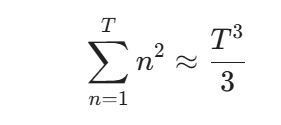

##### Solution : what the KV cache changes

When we add the token n , the keys/ values of the token 1 ... n-1 do not change (the attention is causale : mearning the past do not depend of the futur). So we can keep them in memory. 

Impact : At every step, we calculate the attention only for one new token using the cache => the cost of calcultation for each step O(n) => and the total cost is O(T^2) instead of O(T^3)

### 4- Implementing naive approche without KV cache

Here for each step , we give all the sequence to the model, we collect the logits of the last position , the model generate the next token and we do it again.

=> with this approach, we recalculate the K/V for all the past tokens for every step.


In [12]:
@torch.no_grad()  #  no need for inference (only training) reduce vram consumption
def generate_naive(prompt_ids, max_new_tokens):
    """ 
    Autoregressive generation without KV cache.
    For every step, we give THE ENTIRE sequence to the modele.
    """
    ids = prompt_ids.clone()  # (1, seq_len) stock la séquence pour intput

    for _ in range(max_new_tokens):
        # On passe TOUTE la séquence : Le modèle recalcule ttes les clés/valeurs de tous les tokens, à chaque itération.
        out = model(input_ids=ids, 
                    use_cache=False) # force the model to recalculate entirely

        # logits : (1, seq_len, vocab). On ne garde que la DERNIÈRE position, c'est elle qui prédit le token suivant.
        next_logits = out.logits[:, -1, :]

        #  take the token with the highest probabulity
        next_id = next_logits.argmax(dim=-1, keepdim=True)  # (1, 1)

        #  concatenate all of it
        ids = torch.cat([ids, next_id], dim=1)

    return ids

### 5- Implementing naive approache with KV cach

We use Hugging Face implementation use_cache=True, sending to the model the key /values already calculated (past_ket_values).

The mecanism changes: 
- Step 1: we give all the prompt and we collect the cache
- Next steps : We give only one token (the last one ) with the cache. The modele calculate the attention of this new token using the KV values in memory, then gives the cache.

=> the saving in compute is done because the model calculate only for the new token at each step.

In [13]:
@torch.no_grad()
def generate_with_cache(prompt_ids, max_new_tokens):
    """
    Autoregressive generation without KV cache.
    For every step, we only give one token plus the past K/V
    """
    ids = prompt_ids.clone()

    # prefill step : input all the prompt 
    out = model(input_ids=ids, use_cache=True)
    past = out.past_key_values          # KV cache
    next_logits = out.logits[:, -1, :]
    next_id = next_logits.argmax(dim=-1, keepdim=True)
    ids = torch.cat([ids, next_id], dim=1)

    # generating tokens one by one 
    for _ in range(max_new_tokens - 1):
        # we only give the last token +  cache.
        # => the model do not have to recalculate the past
        out = model(input_ids=next_id, past_key_values=past, use_cache=True)

        past = out.past_key_values       # update cach
        next_logits = out.logits[:, -1, :]
        next_id = next_logits.argmax(dim=-1, keepdim=True)
        ids = torch.cat([ids, next_id], dim=1)

    return ids

### 6- Measuring the speed

We want to measure the two approachs for different generation lengths. 
Expectations : 
- The method without KV cache to be slower (cout cubique) than the one with the cache (cout quadratique)

Mod op : 
- In the GPU the calculations are async so we synchronise before measuring time and we do some warmup to have the more relable values.

In [14]:
def timed(fn, *args, repeats=3):
    """Mesure le temps médian d'exécution d'une fonction (en secondes)."""
    # Warmup phase
    fn(*args)
    if device == "cuda":
        torch.cuda.synchronize()

    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        fn(*args)
        if device == "cuda":
            torch.cuda.synchronize()
        times.append(time.perf_counter() - t0)
    times.sort()
    return times[len(times)//2]  # médiane

In [15]:
prompt = "The history of artificial intelligence began"
prompt_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)


In [16]:
lengths = [16, 32, 64, 128, 192, 220, 250, 350, 400, 550, 750, 1000]

results = {"len": [], "naive": [], "cache": []}

for L in lengths:
    t_naive = timed(generate_naive, prompt_ids, L)
    t_cache = timed(generate_with_cache, prompt_ids, L)
    results["len"].append(L)
    results["naive"].append(t_naive)
    results["cache"].append(t_cache)
    print(f"{L:4d} tokens | naïf : {t_naive:6.3f}s | cache : {t_cache:6.3f}s "
          f"| accélération x{t_naive/t_cache:4.1f}")

  16 tokens | naïf :  0.111s | cache :  0.081s | accélération x 1.4
  32 tokens | naïf :  0.178s | cache :  0.155s | accélération x 1.2
  64 tokens | naïf :  0.452s | cache :  0.216s | accélération x 2.1
 128 tokens | naïf :  0.712s | cache :  0.413s | accélération x 1.7
 192 tokens | naïf :  1.089s | cache :  0.584s | accélération x 1.9
 220 tokens | naïf :  1.263s | cache :  0.728s | accélération x 1.7
 250 tokens | naïf :  1.845s | cache :  0.805s | accélération x 2.3
 350 tokens | naïf :  2.329s | cache :  1.139s | accélération x 2.0
 400 tokens | naïf :  2.034s | cache :  1.294s | accélération x 1.6
 550 tokens | naïf :  3.367s | cache :  1.960s | accélération x 1.7
 750 tokens | naïf :  6.020s | cache :  3.193s | accélération x 1.9
1000 tokens | naïf :  7.431s | cache :  3.922s | accélération x 1.9


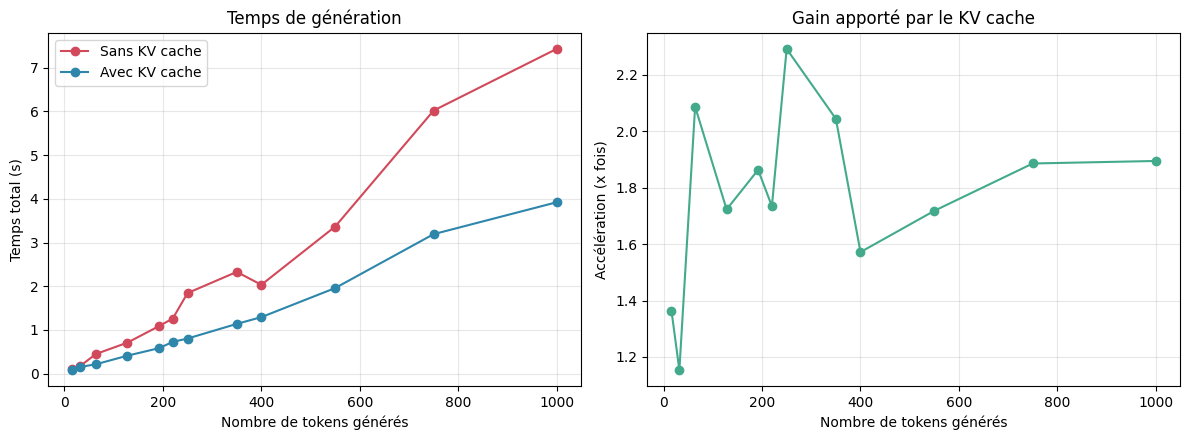

In [17]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(results["len"], results["naive"], "o-", label="Sans KV cache", color="#d1495b")
ax1.plot(results["len"], results["cache"], "o-", label="Avec KV cache", color="#2e86ab")
ax1.set_xlabel("Nombre de tokens générés")
ax1.set_ylabel("Temps total (s)")
ax1.set_title("Temps de génération")
ax1.legend()
ax1.grid(True, alpha=0.3)

speedup = [n/c for n, c in zip(results["naive"], results["cache"])]
ax2.plot(results["len"], speedup, "o-", color="#43aa8b")
ax2.set_xlabel("Nombre de tokens générés")
ax2.set_ylabel("Accélération (x fois)")
ax2.set_title("Gain apporté par le KV cache")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()